In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [249]:
import kagglehub
path = kagglehub.dataset_download("uciml/iris", output_dir="uciml_iris")


In [250]:
data = pd.read_csv("uciml_iris/Iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [251]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


---

In [252]:
data.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [253]:
data.describe().round(2)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20
std,43.45,0.83,0.43,1.76,0.76
min,1.00,4.30,2.00,1.00,0.10
25%,38.25,5.10,2.80,1.60,0.30
50%,75.50,5.80,3.00,4.35,1.30
75%,112.75,6.40,3.30,5.10,1.80
max,150.00,7.90,4.40,6.90,2.50


---

In [254]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
target = 'Species'

In [255]:
from sklearn.preprocessing import LabelEncoder

X = data[features]
y = data[target]

le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [256]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42)

X_train = np.asarray(X_train, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.int32)
y_test = np.asarray(y_test, dtype=np.int32)


In [257]:
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)

In [258]:
y_test

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.]])

---

In [259]:
import seaborn as sns
# sns.pairplot(data, hue="Species", diag_kind="kde")
# plt.show()

In [260]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(len(features),)))
model.add(keras.layers.Dense(8, activation='relu'))
# model.add(keras.layers.Dense(8, activation='relu'))
model.add(keras.layers.Dense(3, activation='softmax'))

In [261]:
model.compile(
    loss=keras.losses.CategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        keras.metrics.CategoricalAccuracy(name="accuracy"),
    ],
)

In [262]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [263]:
batch_size = 16
epochs = 100

callbacks = [
    # keras.callbacks.ModelCheckpoint(filepath="epochs/model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

history = model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.15,
    callbacks=callbacks,
)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3529 - loss: 1.5394 - val_accuracy: 0.2222 - val_loss: 1.6036
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3529 - loss: 1.4746 - val_accuracy: 0.2222 - val_loss: 1.5295
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3529 - loss: 1.4192 - val_accuracy: 0.2222 - val_loss: 1.4641
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3529 - loss: 1.3697 - val_accuracy: 0.2222 - val_loss: 1.4047
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3529 - loss: 1.3301 - val_accuracy: 0.2222 - val_loss: 1.3537
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3529 - loss: 1.2956 - val_accuracy: 0.2222 - val_loss: 1.3117
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3529 - loss: 1.2646 - val_accuracy: 0.2222 - val_loss: 1.2724
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3529 - loss: 1.2386 - val_accuracy: 0.2222 - val_loss: 1.2347

In [264]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy}, len: {len(X_test)}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9667 - loss: 0.4136
Accuracy: 0.9666666388511658, len: 30


In [265]:
epochs = range(1, len(history.history['accuracy']) + 1)

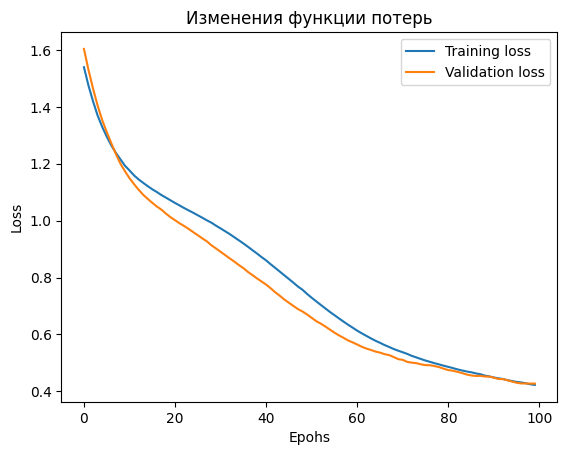

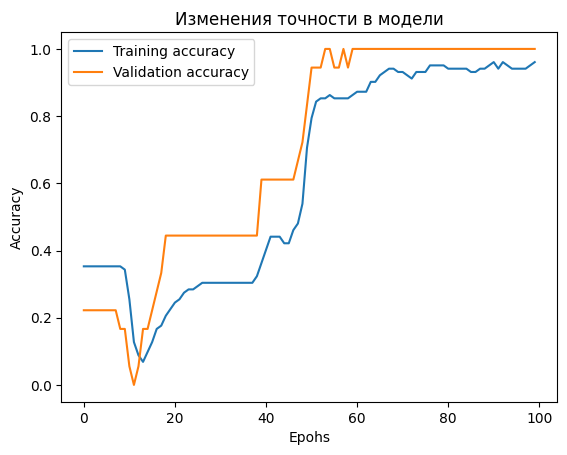

In [266]:
plt.plot(history.epoch, history.history['loss'],
         label='Training loss')
plt.plot(history.epoch, history.history['val_loss'],
         label='Validation loss')
plt.xlabel('Epohs')
plt.ylabel('Loss')
plt.title('Изменения функции потерь')
plt.legend()
plt.show()

plt.plot(history.epoch, history.history['accuracy'],
         label='Training accuracy')
plt.plot(history.epoch, history.history['val_accuracy'],
         label='Validation accuracy')
plt.xlabel('Epohs')
plt.ylabel('Accuracy')
plt.title('Изменения точности в модели')
plt.legend()